# Social Network Analysis

This notebook demonstrates various graph algorithms commonly used in social network analysis:
- Random walks
- Hitting and commute time
- Centrality measures
- MCL clustering algorithm
- PageRank algorithm

In [1]:
!pip install networkx


[notice] A new release of pip is available: 25.0.1 -> 25.1.1
[notice] To update, run: pip install --upgrade pip

[notice] A new release of pip is available: 25.0.1 -> 25.1.1
[notice] To update, run: pip install --upgrade pip


## Random Walks and Network Measures

Random walks are fundamental for understanding information flow in networks.

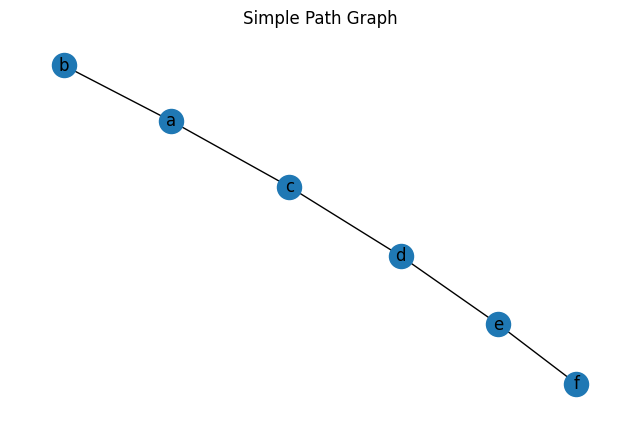

Random walk from 'a': ['a', 'b', 'a', 'b', 'a', 'b', 'a', 'c', 'a', 'b']
Steps from 'a' to 'f': 12
Average hitting time from 'a' to 'f': 18.42
Average commute time between 'a' and 'f': 40.84


In [2]:
import networkx as nx
import random
import matplotlib.pyplot as plt

# Create a simple graph
G = nx.Graph()
edges = [ ('a','b'), ('a','c'), ('c','d'),('d','e'), ('e','f')]
G.add_edges_from(edges)

# Visualize the graph
plt.figure(figsize=(8, 5))
nx.draw_networkx(G)
plt.axis('off')
plt.title("Simple Path Graph")
plt.show()

# Basic random walk implementation
def random_walk(G, start_node, wlen):
    current = start_node
    walk = [start_node]
    for i in range(wlen-1):
        neighbours = list(G.neighbors(current))
        if neighbours:
            next_node = random.choice(neighbours)
            walk.append(next_node)
            current = next_node
        else:
            break
    return walk

# Calculate steps in random walk to reach target
def random_walk_until_target(G, start, target):
    steps = 0
    current = start
    
    while current != target:
        neighbours = list(G.neighbors(current))
        current = random.choice(neighbours)
        steps += 1
    
    return steps

# Compute Average Hitting Time
def compute_hitting_time(G, start, target, simulations=1000):
    total_steps = 0
    for _ in range(simulations):
        total_steps += random_walk_until_target(G, start, target)
    return total_steps / simulations

# Compute Commute Time
def compute_commute_time(G, start, target, simulations=1000):
    hit_start_to_target = compute_hitting_time(G, start, target, simulations)
    hit_target_to_start = compute_hitting_time(G, target, start, simulations)
    return hit_start_to_target + hit_target_to_start

# Run examples
walk_result = random_walk(G, 'a', 10)
print(f"Random walk from 'a': {walk_result}")

steps = random_walk_until_target(G, 'a', 'f')
print(f"Steps from 'a' to 'f': {steps}")

hit_time = compute_hitting_time(G, 'a', 'f', simulations=100)
print(f"Average hitting time from 'a' to 'f': {hit_time:.2f}")

commute_time = compute_commute_time(G, 'a', 'f', simulations=100)
print(f"Average commute time between 'a' and 'f': {commute_time:.2f}")

## Centrality Measures

Centrality measures help identify important nodes in the network.

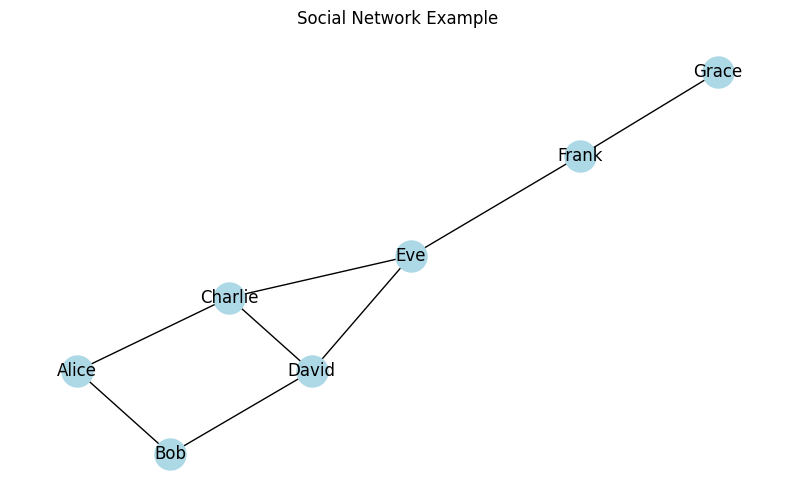

Degree Centrality:
Alice: 0.33
Bob: 0.33
Charlie: 0.50
David: 0.50
Eve: 0.50
Frank: 0.33
Grace: 0.17

Closeness Centrality:
Alice: 0.46
Bob: 0.46
Charlie: 0.60
David: 0.60
Eve: 0.67
Frank: 0.50
Grace: 0.35

Betweenness Centrality:
Alice: 0.03
Bob: 0.03
Charlie: 0.23
David: 0.23
Eve: 0.53
Frank: 0.33
Grace: 0.00

Proximity Prestige:
Alice: 0.46
Bob: 0.46
Charlie: 0.60
David: 0.60
Eve: 0.67
Frank: 0.50
Grace: 0.35


In [3]:
# Create a social network example
G_social = nx.Graph()
edges = [
    ('Alice', 'Bob'), ('Alice', 'Charlie'),
    ('Bob', 'David'), ('Charlie', 'David'),
    ('Charlie', 'Eve'), ('David', 'Eve'),
    ('Eve', 'Frank'), ('Frank', 'Grace')
]
G_social.add_edges_from(edges)

# Visualize the social network
plt.figure(figsize=(10, 6))
nx.draw_networkx(G_social, node_color='lightblue', node_size=500, font_size=12)
plt.title("Social Network Example")
plt.axis('off')
plt.show()

# Compute centrality measures
degree_centrality = nx.degree_centrality(G_social)
closeness_centrality = nx.closeness_centrality(G_social)
betweenness_centrality = nx.betweenness_centrality(G_social)
proximity_prestige = closeness_centrality  # same interpretation

# Print results
print("Degree Centrality:")
for node, centrality in degree_centrality.items():
    print(f"{node}: {centrality:.2f}")

print("\nCloseness Centrality:")
for node, centrality in closeness_centrality.items():
    print(f"{node}: {centrality:.2f}")

print("\nBetweenness Centrality:")
for node, centrality in betweenness_centrality.items():
    print(f"{node}: {centrality:.2f}")

print("\nProximity Prestige:")
for node, prestige in proximity_prestige.items():
    print(f"{node}: {prestige:.2f}")

## MCL Algorithm and PageRank

MCL is used for community detection, while PageRank identifies influential nodes.

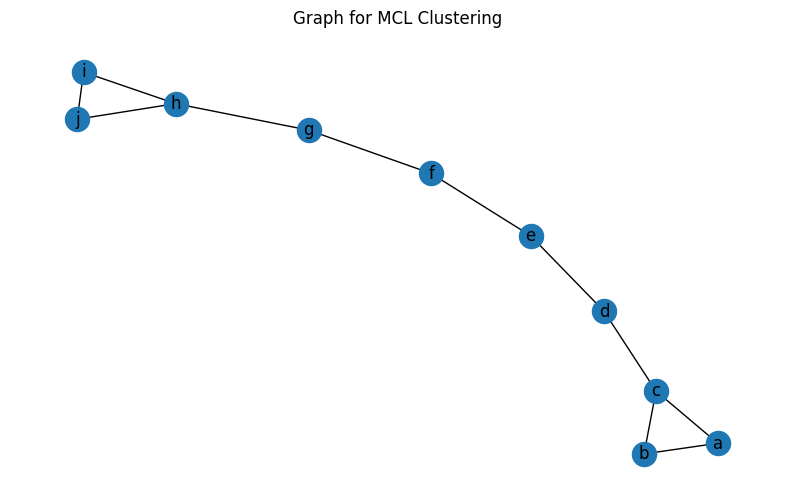

MCL Clusters found:
Cluster 1: {'a', 'b', 'c'}
Cluster 2: {'f', 'e', 'd', 'g'}
Cluster 3: {'j', 'i', 'h'}


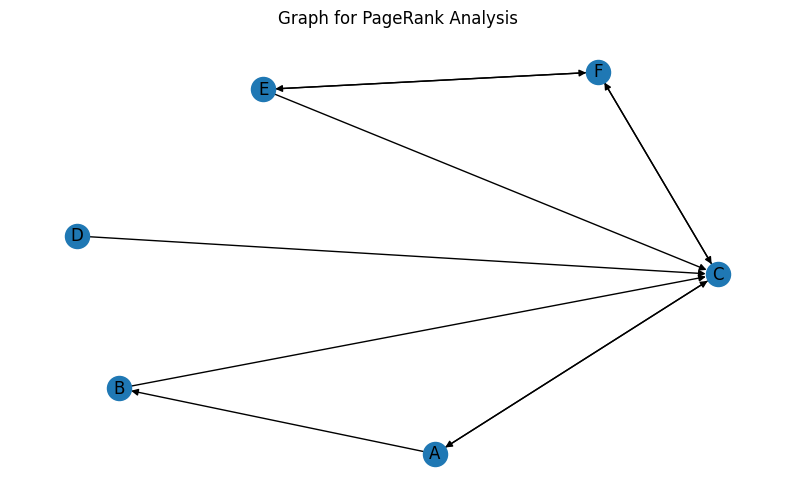


PageRank scores:
Page A has rank: 0.1750
Page B has rank: 0.0994
Page C has rank: 0.3529
Page D has rank: 0.0250
Page E has rank: 0.1213
Page F has rank: 0.2265


In [4]:
import numpy as np

# MCL Algorithm Implementation
def create_adjacency_matrix(G):
    A = nx.to_numpy_array(G)
    np.fill_diagonal(A, 1)  # Add self-loops
    return A

def normalize(M):
    column_sums = M.sum(axis=0)
    return M / column_sums

def expand(M, power):
    return np.linalg.matrix_power(M, power)

def inflate(M, inflation_factor):
    M = np.power(M, inflation_factor)
    return normalize(M)

def mcl(G, expand_power=2, inflate_power=2, iterations=10):
    M = create_adjacency_matrix(G)
    M = normalize(M)
    
    for i in range(iterations):
        M = expand(M, expand_power)
        M = inflate(M, inflate_power)
    
    return M

def get_clusters(M, nodes, threshold=0.01):
    clusters = []
    seen = set()
    for i, row in enumerate(M):
        if nodes[i] not in seen:
            cluster = set([nodes[j] for j, val in enumerate(row) if val > threshold])
            if cluster:
                clusters.append(cluster)
                seen.update(cluster)
    return clusters

# Create a test graph for MCL
G_mcl = nx.Graph()
edges = [ 
    ('a','b'), ('a','c'), ('b','c'), ('c','d'),
    ('d','e'), ('e','f'), ('f','g'), ('g','h'),
    ('h','i'), ('i','j'), ('j','h')
]
G_mcl.add_edges_from(edges)

# Visualize the MCL test graph
plt.figure(figsize=(10, 6))
nx.draw_networkx(G_mcl)
plt.title("Graph for MCL Clustering")
plt.axis('off')
plt.show()

# Run MCL
M = mcl(G_mcl, 2, 2, iterations=15)
nodes = list(G_mcl.nodes())
clusters = get_clusters(M, nodes)

print("MCL Clusters found:")
for idx, cluster in enumerate(clusters):
    print(f"Cluster {idx+1}: {cluster}")

# PageRank Implementation
def pagerank(G, damping=0.85, max_iterations=100):
    # Initialize
    N = G.number_of_nodes()
    ranks = {node: 1 / N for node in G}  # initial rank for each node
    
    for i in range(max_iterations):
        new_ranks = {}
        for node in G:
            rank_sum = 0
            for neighbor in G.predecessors(node):  # incoming edges
                out_degree = G.out_degree(neighbor)
                if out_degree > 0:
                    rank_sum += ranks[neighbor] / out_degree
            new_ranks[node] = (1 - damping) / N + damping * rank_sum
        
        ranks = new_ranks
    return ranks

# Create a directed graph for PageRank
G_pr = nx.DiGraph()
edges = [
    ('A', 'B'), ('A', 'C'), ('B', 'C'), ('C', 'A'),
    ('D', 'C'), ('E', 'C'), ('F', 'C'), ('C', 'F'),
    ('E', 'F'), ('F', 'E')
]
G_pr.add_edges_from(edges)

# Visualize the PageRank graph
plt.figure(figsize=(10, 6))
nx.draw_networkx(G_pr)
plt.title("Graph for PageRank Analysis")
plt.axis('off')
plt.show()

# Compute PageRank
page_ranks = pagerank(G_pr)

# Print the results
print("\nPageRank scores:")
for page, rank in page_ranks.items():
    print(f"Page {page} has rank: {rank:.4f}")

## Summary

This notebook demonstrated various graph algorithms for social network analysis:
1. Random walks and hitting time calculations
2. Centrality measures for identifying important nodes
3. MCL algorithm for community detection
4. PageRank for measuring node influence

These algorithms provide valuable insights into network structure and dynamics.